In [1]:
import os
from plotnine import *
import polars as pl
import pandas as pd
import pairadigm as pdm

In [3]:
# Fix all_tables_item_scores.csv

DIRECTORIES = [
    "gilbert_meta_2", 
    "gilbert_meta_102", 
    "gilbert_meta_103",
    "gilbert_meta_104"
]

all_tables_item_scores_dfs = []
for dir in DIRECTORIES:
    df = pd.read_csv(f"../results/{dir}/{dir}_all_item_scores.csv")
    all_tables_item_scores_dfs.append(df)

all_tables_item_scores_df = pd.concat(all_tables_item_scores_dfs, ignore_index=True)
all_tables_item_scores_df.to_csv("../results/all_tables_item_scores.csv", index=False)

In [4]:
all_tables_item_scores_df.columns

Index(['item', 'section_prompt', 'item_text', 'combined_text',
       'CGCoT_Breakdown_gemini-3-flash-preview',
       'CGCoT_Breakdown_gpt-5.4-mini',
       'Bradley_Terry_Score_gemini-3-flash-preview',
       'Bradley_Terry_SE_gemini-3-flash-preview',
       'Bradley_Terry_Score_gpt-5.4-mini', 'Bradley_Terry_SE_gpt-5.4-mini',
       'a', 'b', 'table'],
      dtype='str')

In [20]:
all_tables_item_scores_df_long = (
    pd.wide_to_long(
        all_tables_item_scores_df,
        stubnames=["Bradley_Terry_Score", "Bradley_Terry_SE"],
        i=["item", "table", "a", "b"],  # keep these fixed
        j="model",                              # model/table name extracted here
        sep="_",
        suffix=".+",                            # allows names like gemini-3-flash-preview
    )
    .reset_index()
    .rename(
        columns={
            "Bradley_Terry_Score": "score",
            "Bradley_Terry_SE": "SE",
        }
    )
)

all_tables_item_scores_df_long.head()

,item,table,a,b,model,CGCoT_Breakdown_gemini-3-flash-preview,CGCoT_Breakdown_gpt-5.4-mini,combined_text,item_text,section_prompt,score,SE
0,20,gilbert_meta_2,2.039108,-0.495678,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is similar about the work that paleontolo...,Teacher Directions to Read Aloud: “Now you wil...,3.000000,4.003638
1,20,gilbert_meta_2,2.039108,-0.495678,gpt-5.4-mini,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is similar about the work that paleontolo...,Teacher Directions to Read Aloud: “Now you wil...,0.527728,0.958699
2,15,gilbert_meta_2,3.282003,-0.556399,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,"According to the passage, who uses clues to fi...",Teacher Directions to Read Aloud: “Now you wil...,-3.000000,0.109184
3,15,gilbert_meta_2,3.282003,-0.556399,gpt-5.4-mini,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,"According to the passage, who uses clues to fi...",Teacher Directions to Read Aloud: “Now you wil...,-2.979776,0.180543
4,19,gilbert_meta_2,1.492890,-0.170499,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is one reason people want to find ancestors?,Teacher Directions to Read Aloud: “Now you wil...,0.386963,0.627291


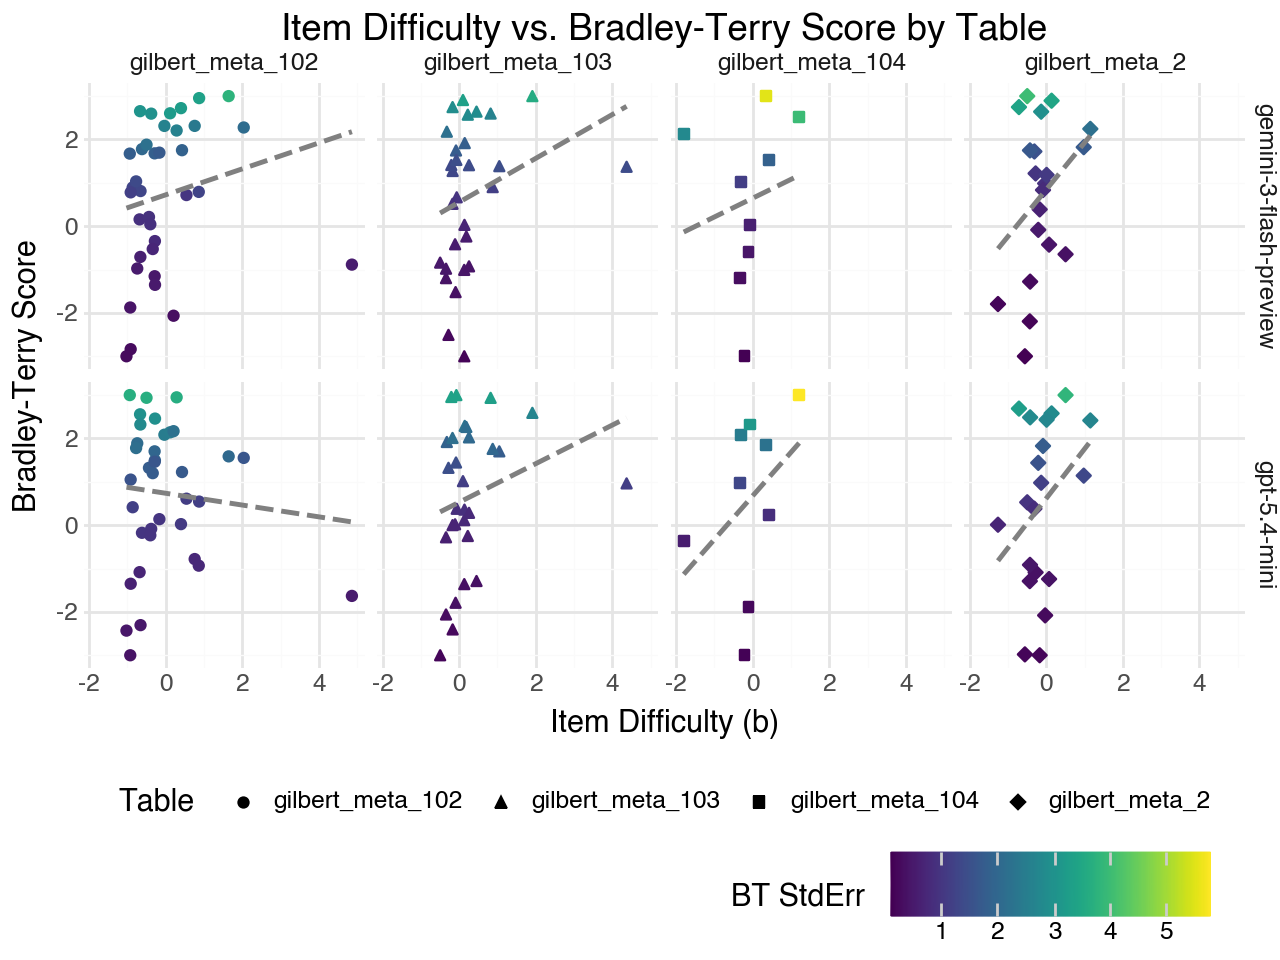

In [26]:
(
    ggplot(
        all_tables_item_scores_df_long,
        aes(
            x="b",
            y="score",
            shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("model~table")
    + labs(title="Item Difficulty vs. Bradley-Terry Score by Table",
            x="Item Difficulty (b)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

In [29]:
# Calculate the Spearman correlation and its p-value for each table and model combination
correlations = (
    all_tables_item_scores_df_long
    .groupby(["table", "model"])
    .apply(lambda df: pd.Series({
        "spearman_corr": df["b"].corr(df["score"], method="spearman"),
        "p_value": df["b"].corr(df["score"], method="spearman")
    }))
    .reset_index()
)
print(correlations)

              table                   model  spearman_corr   p_value
0  gilbert_meta_102  gemini-3-flash-preview       0.417503  0.417503
1  gilbert_meta_102            gpt-5.4-mini       0.060232  0.060232
2  gilbert_meta_103  gemini-3-flash-preview       0.354187  0.354187
3  gilbert_meta_103            gpt-5.4-mini       0.329064  0.329064
4  gilbert_meta_104  gemini-3-flash-preview       0.450000  0.450000
5  gilbert_meta_104            gpt-5.4-mini       0.433333  0.433333
6    gilbert_meta_2  gemini-3-flash-preview       0.224060  0.224060
7    gilbert_meta_2            gpt-5.4-mini       0.308271  0.308271
